In [21]:
pip install autogluon

  Using cached autogluon-1.5.0-py3-none-any.whl.metadata (12 kB)
  Using cached autogluon_multimodal-1.5.0-py3-none-any.whl.metadata (13 kB)
  Using cached autogluon_timeseries-1.5.0-py3-none-any.whl.metadata (13 kB)
  Using cached lightning-2.5.6-py3-none-any.whl.metadata (42 kB)
  Using cached transformers-4.57.6-py3-none-any.whl.metadata (43 kB)
  Using cached evaluate-0.4.6-py3-none-any.whl.metadata (9.5 kB)
  Using cached timm-1.0.3-py3-none-any.whl.metadata (43 kB)
  Using cached nlpaug-1.1.11-py3-none-any.whl.metadata (14 kB)
  Using cached openmim-0.3.9-py2.py3-none-any.whl.metadata (16 kB)
  Using cached statsforecast-2.0.1-cp311-cp311-win_amd64.whl.metadata (30 kB)
  Using cached mlforecast-0.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached fugue-0.9.7-py3-none-any.whl.metadata (18 kB)
  Using cached chronos_forecasting-2.2.2-py3-none-any.whl.metadata (23 kB)
  Using cached peft-0.17.1-py3-none-any.whl.metadata (14 kB)
  Using cached pytorch_lightning-2.6.4-py3-none-any.

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
summac 0.0.4 requires huggingface-hub<=0.17.0, but you have huggingface-hub 0.36.2 which is incompatible.

[notice] A new release of pip is available: 25.3 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [22]:
from autogluon.tabular import TabularPredictor
print("AutoGluon imported successfully")

AutoGluon imported successfully


In [23]:

from autogluon.tabular import TabularPredictor
import autogluon

print("AutoGluon successfully imported!")

print("Version:", autogluon.__version__ if hasattr(autogluon, '__version__') else "Version check via submodule")
import autogluon.tabular
print("Tabular Version:", autogluon.tabular.__version__)

AutoGluon successfully imported!
Version: Version check via submodule
Tabular Version: 1.5.0


In [2]:
import pandas as pd
import numpy as np

from autogluon.tabular import TabularPredictor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)


In [3]:
train_df = pd.read_csv(
    r"C:\hireai-ml\data\processed\train.csv"
)

test_df = pd.read_csv(
    r"C:\hireai-ml\data\processed\test.csv"
)

print(train_df.shape)

print(train_df.columns)

print(train_df.head(5))

(79840, 22)
Index(['application_id', 'candidate_id', 'job_id', 'application_date',
       'status', 'name', 'email', 'skills', 'experience_years', 'education',
       'projects', 'role', 'required_skills', 'min_experience', 'score',
       'skills_match', 'experience_score', 'project_score', 'label',
       'num_candidate_skills', 'num_required_skills', 'experience_difference'],
      dtype='object')
   application_id  candidate_id  job_id application_date       status  \
0           66735         30433       7       2026-03-11      applied   
1           64779         29450      10       2025-08-03  interviewed   
2           17695          5854       8       2025-09-27  shortlisted   
3           45409         19740       7       2025-08-16  shortlisted   
4           40653         17363       7       2025-09-12      applied   

               name                              email  \
0          pooja li              pooja.li5775@zoho.com   
1      meera pillai           meera.pilla

In [4]:
drop_columns = [
    'candidate_id',
    'name',
    'email'
]

# Train data preprocessing
train_df.drop(
    columns=drop_columns,
    inplace=True
)

train_df.fillna(
    "Unknown",
    inplace=True
)

# Test data preprocessing
test_df.drop(
    columns=drop_columns,
    inplace=True
)

test_df.fillna(
    "Unknown",
    inplace=True
)

In [5]:
target = "experience_years"

# AutoGluon model
predictor = TabularPredictor(
    label=target,
    problem_type='regression',
    eval_metric='root_mean_squared_error',
    path='Autogluon_Regression_Models'
).fit(

    train_data=train_df,

    presets='medium_quality',

    time_limit=300,

    num_bag_folds=0,

    num_stack_levels=0,

    verbosity=2
)

# Predictions on test data
predictions = predictor.predict(test_df)

# Actual values
y_true = test_df[target]

print(predictions.head())


Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          4
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       6.36 GB / 15.84 GB (40.1%)
Disk Space Avail:   303.55 GB / 476.05 GB (63.8%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Beginning AutoGluon training ... Time limit = 300s
AutoGluon will save models to "c:\hireai-ml\notebooks\Autogluon_Regression_Models"
Train Data Rows:    79840
Train Data Columns: 18
Label Column:       experience_years
Problem Type:       regression
Preprocessing data ...
Using Feature Generators to preprocess the data ...
Fitting AutoMLPipelineFeatureGenerator...
	Available Memory:                    6548.18 MB
	Train Data (Original)  Memory Usage: 60.31 MB (0.9% of available memory)
	I

[1000]	valid_set's rmse: 0.0830703
[2000]	valid_set's rmse: 0.0632238
[3000]	valid_set's rmse: 0.0601856
[4000]	valid_set's rmse: 0.0593455
[5000]	valid_set's rmse: 0.0590163
[6000]	valid_set's rmse: 0.0589113
[7000]	valid_set's rmse: 0.0587875
[8000]	valid_set's rmse: 0.0586113
[9000]	valid_set's rmse: 0.058617
[10000]	valid_set's rmse: 0.0585326


	-0.0585	 = Validation score   (-root_mean_squared_error)
	171.82s	 = Training   runtime
	7.22s	 = Validation runtime
Fitting model: LightGBM ... Training model for up to 91.98s of the 91.98s of remaining time.
	Fitting with cpus=2, gpus=0, mem=0.5/6.2 GB


[1000]	valid_set's rmse: 0.000998955
[2000]	valid_set's rmse: 0.000976544
[3000]	valid_set's rmse: 0.000970816


	-0.001	 = Validation score   (-root_mean_squared_error)
	86.98s	 = Training   runtime
	1.06s	 = Validation runtime
Fitting model: RandomForestMSE ... Training model for up to 2.76s of the 2.76s of remaining time.
	Fitting with cpus=4, gpus=0, mem=0.4/6.2 GB
	Time limit exceeded... Skipping RandomForestMSE.
Fitting model: WeightedEnsemble_L2 ... Training model for up to 275.59s of the -4.95s of remaining time.
	Fitting 1 model on all data | Fitting with cpus=4, gpus=0, mem=0.0/6.1 GB
	Ensemble Weights: {'LightGBM': 1.0}
	-0.001	 = Validation score   (-root_mean_squared_error)
	0.02s	 = Training   runtime
	0.0s	 = Validation runtime
AutoGluon training complete, total runtime = 305.66s ... Best model: WeightedEnsemble_L2 | Estimated inference throughput: 2365.2 rows/s (2499 batch size)
TabularPredictor saved. To load, use: predictor = TabularPredictor.load("c:\hireai-ml\notebooks\Autogluon_Regression_Models")


0    13.000046
1    10.000105
2     1.999981
3    11.999800
4    11.999920
Name: experience_years, dtype: float32


In [6]:
from src.eval.metrics import regression_metrics

results = regression_metrics(
    y_true,
    predictions
)

print(results)

ModuleNotFoundError: No module named 'src'

In [ ]:
import pandas as pd

error_df = pd.DataFrame({
    "actual": y_true,
    "predicted": predictions
})

error_df["error"] = (
    error_df["actual"] -
    error_df["predicted"]
)

print(error_df.head())

    actual  predicted     error
2        6   6.002979 -0.002979
5        9   8.969469  0.030531
15      10  10.004941 -0.004941
20       3   2.992794  0.007206
22       4   3.999665  0.000335


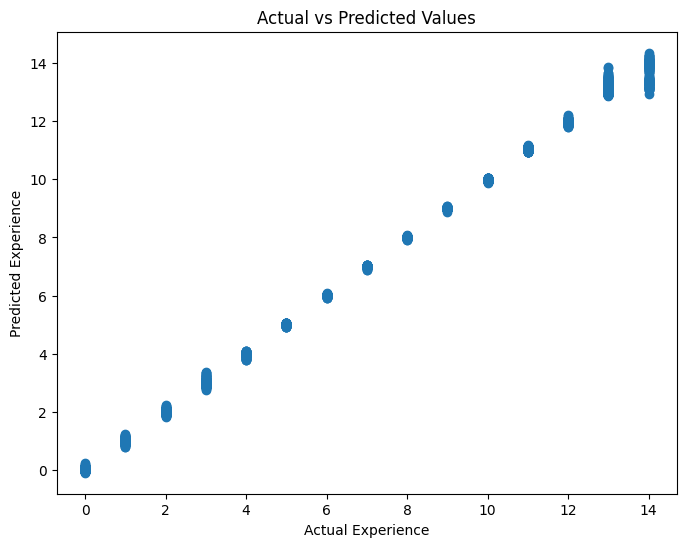

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    y_true,
    predictions
)

plt.xlabel("Actual Experience")
plt.ylabel("Predicted Experience")

plt.title("Actual vs Predicted Values")

plt.show()

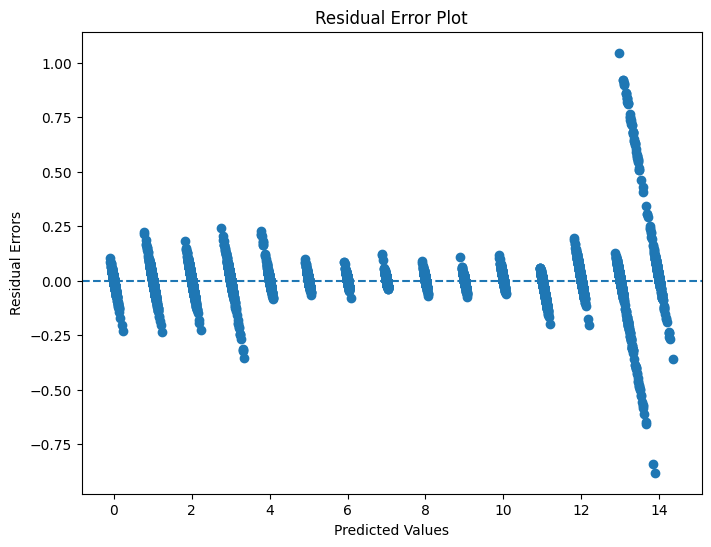

In [ ]:
errors = y_true - predictions

plt.figure(figsize=(8,6))

plt.scatter(
    predictions,
    errors
)

plt.axhline(
    y=0,
    linestyle='--'
)

plt.xlabel("Predicted Values")
plt.ylabel("Residual Errors")

plt.title("Residual Error Plot")

plt.show()

In [7]:
importance_df = predictor.feature_importance(
    test_df.head(100)
)

print(importance_df)

These features in provided data are not utilized by the predictor and will be ignored: ['required_skills']
Computing feature importance via permutation shuffling for 17 features using 100 rows with 5 shuffle sets...
	32.88s	= Expected runtime (6.58s per shuffle set)
	8.64s	= Actual runtime (Completed 5 of 5 shuffle sets)


                       importance    stddev       p_value  n  p99_high  \
experience_difference    5.239351  0.329784  1.873706e-06  5  5.918381   
min_experience           1.306664  0.042758  1.373994e-07  5  1.394704   
experience_score         0.591141  0.044309  3.759555e-06  5  0.682374   
role                     0.001173  0.000551  4.451283e-03  5  0.002307   
education                0.000081  0.000152  1.479225e-01  5  0.000394   
job_id                   0.000047  0.000076  1.197546e-01  5  0.000204   
skills                   0.000045  0.000014  8.840534e-04  5  0.000073   
project_score            0.000022  0.000059  2.198465e-01  5  0.000143   
label                    0.000008  0.000029  2.797631e-01  5  0.000068   
skills_match             0.000005  0.000029  3.591407e-01  5  0.000064   
status                  -0.000004  0.000005  8.954310e-01  5  0.000008   
application_id          -0.000054  0.000080  8.962920e-01  5  0.000111   
num_required_skills     -0.000105  0.0

<Axes: >

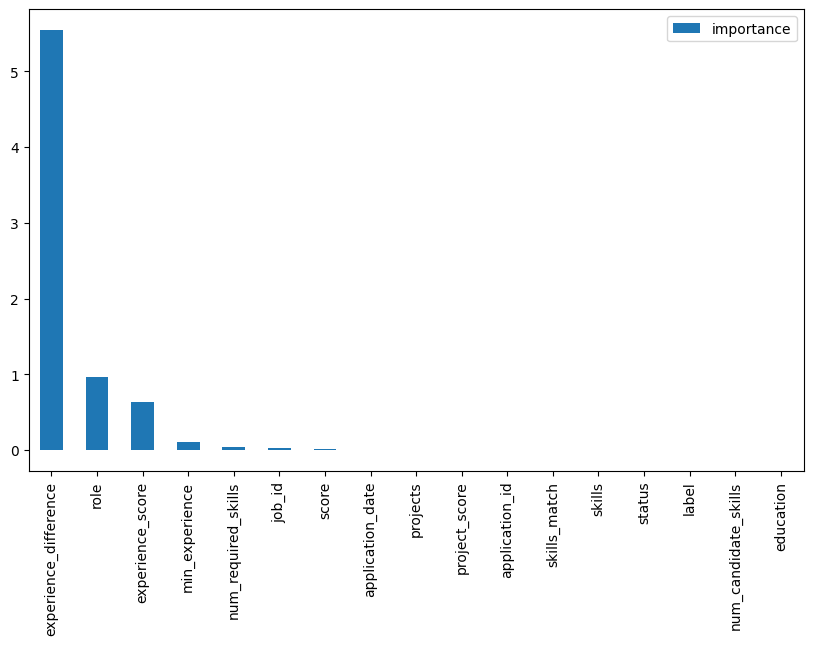

In [ ]:
importance_df.plot.bar(
    y='importance',
    figsize=(10,6)
)

# Final M3 Regression Evaluation Summary

- AutoGluon regression model evaluated successfully
- MAE, RMSE, and R² metrics computed
- Residual analysis performed
- Actual vs predicted visualization generated
- Feature importance extracted for explainability
